# Guía Completa: Detección y Tratamiento de Datos Atípicos (Outliers)

## Objetivos de Aprendizaje

En este notebook aprenderás técnicas esenciales para manejar datos atípicos, incluyendo:

- **Métodos de detección**: Estadísticos, visuales y algorítmicos
- **Técnicas estadísticas**: IQR, Z-Score, métodos robustos
- **Algoritmos avanzados**: Isolation Forest, LOF
- **Estrategias de tratamiento**: Eliminación, transformación, imputación
- **Evaluación de impacto**: Comparación antes/después del tratamiento

Los datos atípicos pueden influir significativamente en los resultados del análisis, por lo que es crucial saber identificarlos y tratarlos adecuadamente.

## 1. Importar Librerías Necesarias

Importaremos todas las librerías que necesitaremos para la detección y tratamiento de datos atípicos.

In [ ]:
# Librerías fundamentales
import pandas as pd
import numpy as np
import scipy.stats as stats

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# pip install scikit-learn
# Librerías de machine learning para detección de anomalías
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# Configuraciones para visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Configurar pandas
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Suprimir warnings
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Librerías importadas correctamente!
Pandas version: 2.2.3
NumPy version: 1.26.4
Matplotlib version: 3.10.1
Seaborn version: 0.13.2


## 2. Cargar y Explorar el Dataset

Crearemos un dataset de ejemplo con datos atípicos para practicar las diferentes técnicas de detección y tratamiento.

In [3]:
# Crear dataset de ejemplo con datos atípicos
np.random.seed(42)

# Generar datos normales
n_samples = 500
normal_data = {
    'id': range(1, n_samples + 1),
    'edad': np.random.normal(35, 8, n_samples),
    'salario': np.random.normal(50000, 12000, n_samples),
    'experiencia': np.random.normal(8, 3, n_samples),
    'ventas': np.random.normal(100000, 20000, n_samples),
    'horas_trabajo': np.random.normal(40, 5, n_samples)
}

# Crear DataFrame
df = pd.DataFrame(normal_data)

# Introducir outliers deliberadamente
outlier_indices = np.random.choice(n_samples, size=25, replace=False)

for idx in outlier_indices[:8]:
    df.loc[idx, 'salario'] = np.random.uniform(150000, 200000)  # Salarios muy altos
    
for idx in outlier_indices[8:15]:
    df.loc[idx, 'edad'] = np.random.uniform(70, 85)  # Edades muy altas
    
for idx in outlier_indices[15:20]:
    df.loc[idx, 'ventas'] = np.random.uniform(300000, 500000)  # Ventas muy altas
    
for idx in outlier_indices[20:]:
    df.loc[idx, 'horas_trabajo'] = np.random.uniform(70, 90)  # Horas excesivas

# Asegurar valores positivos donde sea apropiado
df['edad'] = np.abs(df['edad'])
df['salario'] = np.abs(df['salario'])
df['experiencia'] = np.abs(df['experiencia'])
df['ventas'] = np.abs(df['ventas'])
df['horas_trabajo'] = np.abs(df['horas_trabajo'])

print("Dataset creado con éxito!")
print(f"Forma del dataset: {df.shape}")
print("\nPrimeras 10 filas:")
print(df.head(10))

Dataset creado con éxito!
Forma del dataset: (500, 6)

Primeras 10 filas:
   id       edad       salario  experiencia         ventas  horas_trabajo
0   1  38.973713  61114.130570    12.198066  115567.221523      36.624109
1   2  33.893886  72912.999686    10.773901   88976.285673      39.277407
2   3  40.181508  33217.189114     8.178891   83636.022332      36.037900
3   4  47.184239  56755.630840     6.059190   99932.510852      38.460192
4   5  33.126773  42192.289171    10.094670   96596.307550      30.531927
5   6  33.126904  44154.495395     9.180456   90935.439013      41.066469
6   7  47.633703  42891.272909    10.685580  113927.748949      40.006027
7   8  41.139478  39632.110764     9.905515  119106.104171      35.914557
8   9  31.244205  50582.259535    11.148658  101768.137726      43.296228
9  10  39.340480  40028.598603     6.394294  129550.601621      79.690760


Estadísticas descriptivas:
               id        edad        salario  experiencia         ventas  horas_trabajo
count  500.000000  500.000000     500.000000   500.000000     500.000000     500.000000
mean   250.500000   35.669759   52244.650648     8.330391  103160.597549      40.290983
std    144.481833    9.115873   19633.489090     3.017114   33135.515898       6.184265
min      1.000000    9.069861   17637.360285     0.226873   41192.227307      24.902439
25%    125.750000   29.534032   43030.791402     6.192711   87927.709159      36.696318
50%    250.500000   35.370210   50351.005775     8.359418  100252.718928      39.998746
75%    375.250000   40.377231   58117.877522    10.264215  114267.256191      43.355379
max    500.000000   82.135355  198388.073263    15.805049  472931.784372      86.076098

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  --

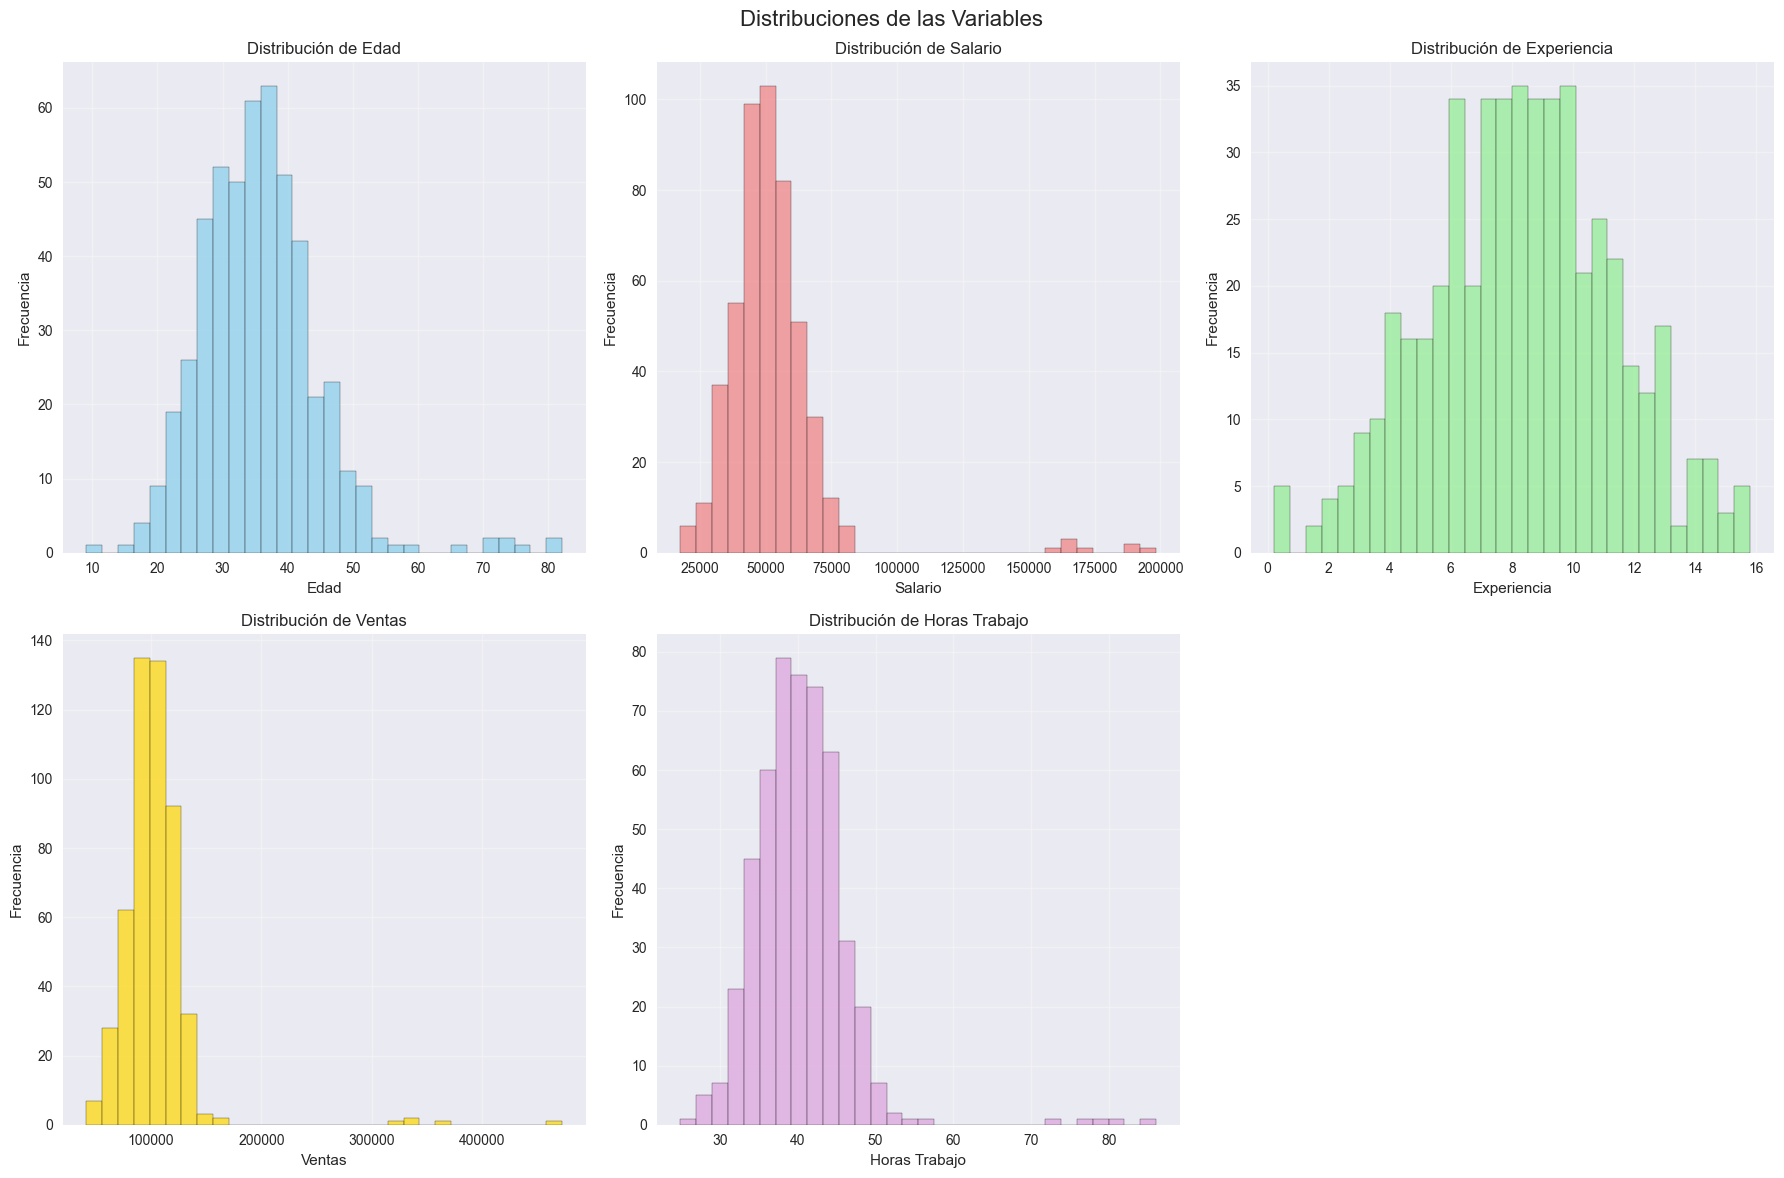

In [4]:
# Estadísticas descriptivas del dataset
print("Estadísticas descriptivas:")
print(df.describe())

print("\nInformación del dataset:")
print(df.info())

# Visualización inicial de las distribuciones
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribuciones de las Variables', fontsize=16)

variables = ['edad', 'salario', 'experiencia', 'ventas', 'horas_trabajo']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']

for i, var in enumerate(variables):
    row, col = divmod(i, 3)
    axes[row, col].hist(df[var], bins=30, alpha=0.7, color=colors[i], edgecolor='black')
    axes[row, col].set_title(f'Distribución de {var.replace("_", " ").title()}')
    axes[row, col].set_xlabel(var.replace("_", " ").title())
    axes[row, col].set_ylabel('Frecuencia')
    axes[row, col].grid(True, alpha=0.3)

# Remover el subplot vacío
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

## 3. Detectar Datos Atípicos con Métodos Estadísticos

Comenzaremos con métodos estadísticos básicos para identificar valores que se desvían significativamente de la distribución normal.

In [5]:
# Función para detectar outliers usando estadísticas básicas
def detectar_outliers_estadisticos(serie, metodo='std', factor=3):
    """
    Detecta outliers usando métodos estadísticos básicos
    
    Parámetros:
    - serie: pandas Series con los datos
    - metodo: 'std' para desviación estándar, 'mad' para desviación absoluta mediana
    - factor: número de desviaciones estándar para considerar outlier
    """
    if metodo == 'std':
        media = serie.mean()
        std = serie.std()
        limite_inferior = media - (factor * std)
        limite_superior = media + (factor * std)
    elif metodo == 'mad':
        mediana = serie.median()
        mad = stats.median_abs_deviation(serie)
        limite_inferior = mediana - (factor * mad)
        limite_superior = mediana + (factor * mad)
    
    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    return outliers, limite_inferior, limite_superior

# Aplicar detección estadística a cada variable
variables_numericas = ['edad', 'salario', 'experiencia', 'ventas', 'horas_trabajo']

print("DETECCIÓN DE OUTLIERS USANDO DESVIACIÓN ESTÁNDAR (±3σ)")
print("=" * 60)

outliers_estadisticos = {}
for var in variables_numericas:
    outliers, limite_inf, limite_sup = detectar_outliers_estadisticos(df[var])
    outliers_estadisticos[var] = outliers
    
    print(f"\n{var.upper().replace('_', ' ')}:")
    print(f"  Límite inferior: {limite_inf:.2f}")
    print(f"  Límite superior: {limite_sup:.2f}")
    print(f"  Número de outliers: {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Valores outliers: {outliers.values[:5]}")  # Mostrar solo los primeros 5

DETECCIÓN DE OUTLIERS USANDO DESVIACIÓN ESTÁNDAR (±3σ)

EDAD:
  Límite inferior: 8.32
  Límite superior: 63.02
  Número de outliers: 8
  Valores outliers: [70.93847263 73.15760409 73.84694592 65.82185193 75.32979623]

SALARIO:
  Límite inferior: -6655.82
  Límite superior: 111145.12
  Número de outliers: 8
  Valores outliers: [187964.62534592 164969.16868527 166312.69590206 198388.07326348
 171987.0243254 ]

EXPERIENCIA:
  Límite inferior: -0.72
  Límite superior: 17.38
  Número de outliers: 0

VENTAS:
  Límite inferior: 3754.05
  Límite superior: 202567.15
  Número de outliers: 5
  Valores outliers: [329384.38471675 472931.78437163 316547.36712364 368529.0293045
 330985.06222869]

HORAS TRABAJO:
  Límite inferior: 21.74
  Límite superior: 58.84
  Número de outliers: 5
  Valores outliers: [79.6907599  86.07609781 81.26816729 76.04839023 72.74296976]


## 4. Detectar Datos Atípicos con Visualizaciones

Las visualizaciones son herramientas poderosas para identificar outliers de manera intuitiva.

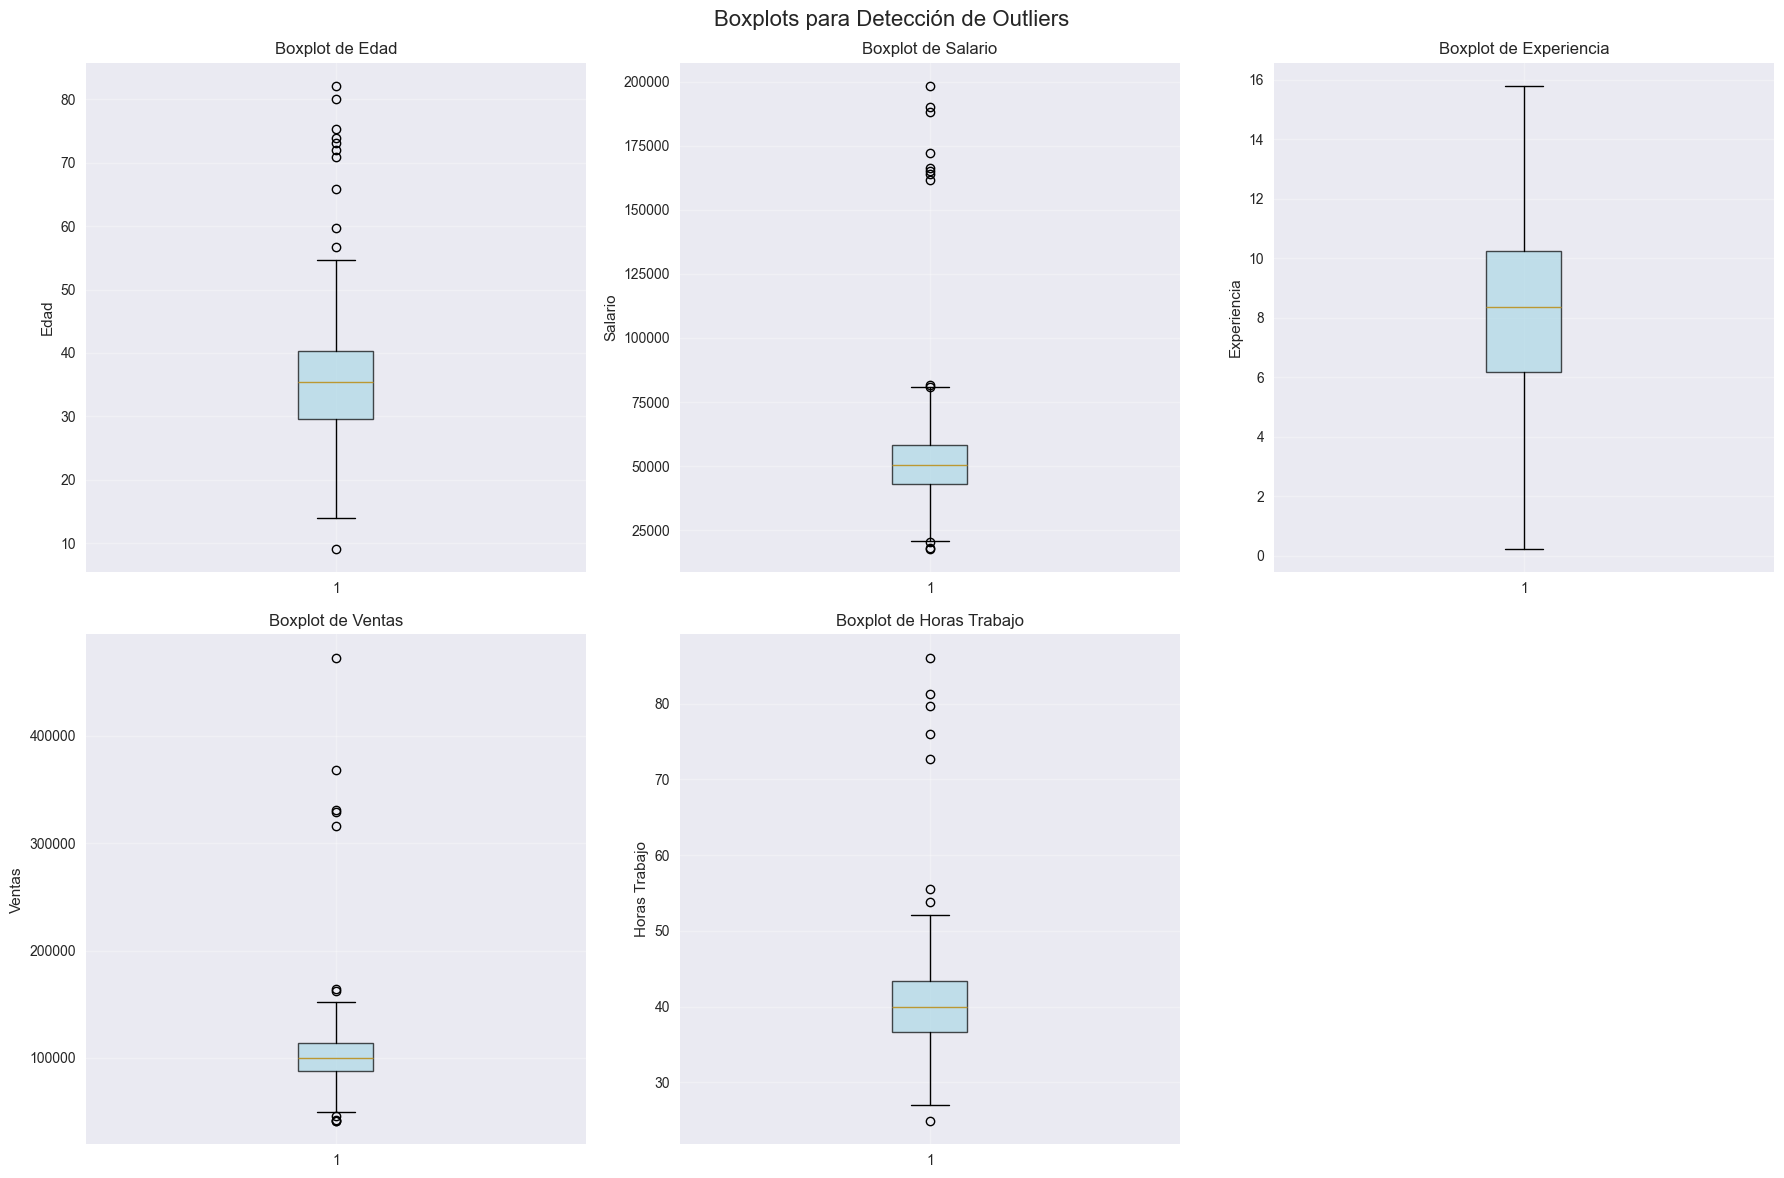

In [6]:
# Boxplots para visualizar outliers
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Boxplots para Detección de Outliers', fontsize=16)

for i, var in enumerate(variables_numericas):
    row, col = divmod(i, 3)
    box_plot = axes[row, col].boxplot(df[var], patch_artist=True)
    axes[row, col].set_title(f'Boxplot de {var.replace("_", " ").title()}')
    axes[row, col].set_ylabel(var.replace("_", " ").title())
    axes[row, col].grid(True, alpha=0.3)
    
    # Colorear el boxplot
    box_plot['boxes'][0].set_facecolor('lightblue')
    box_plot['boxes'][0].set_alpha(0.7)

# Remover el subplot vacío
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

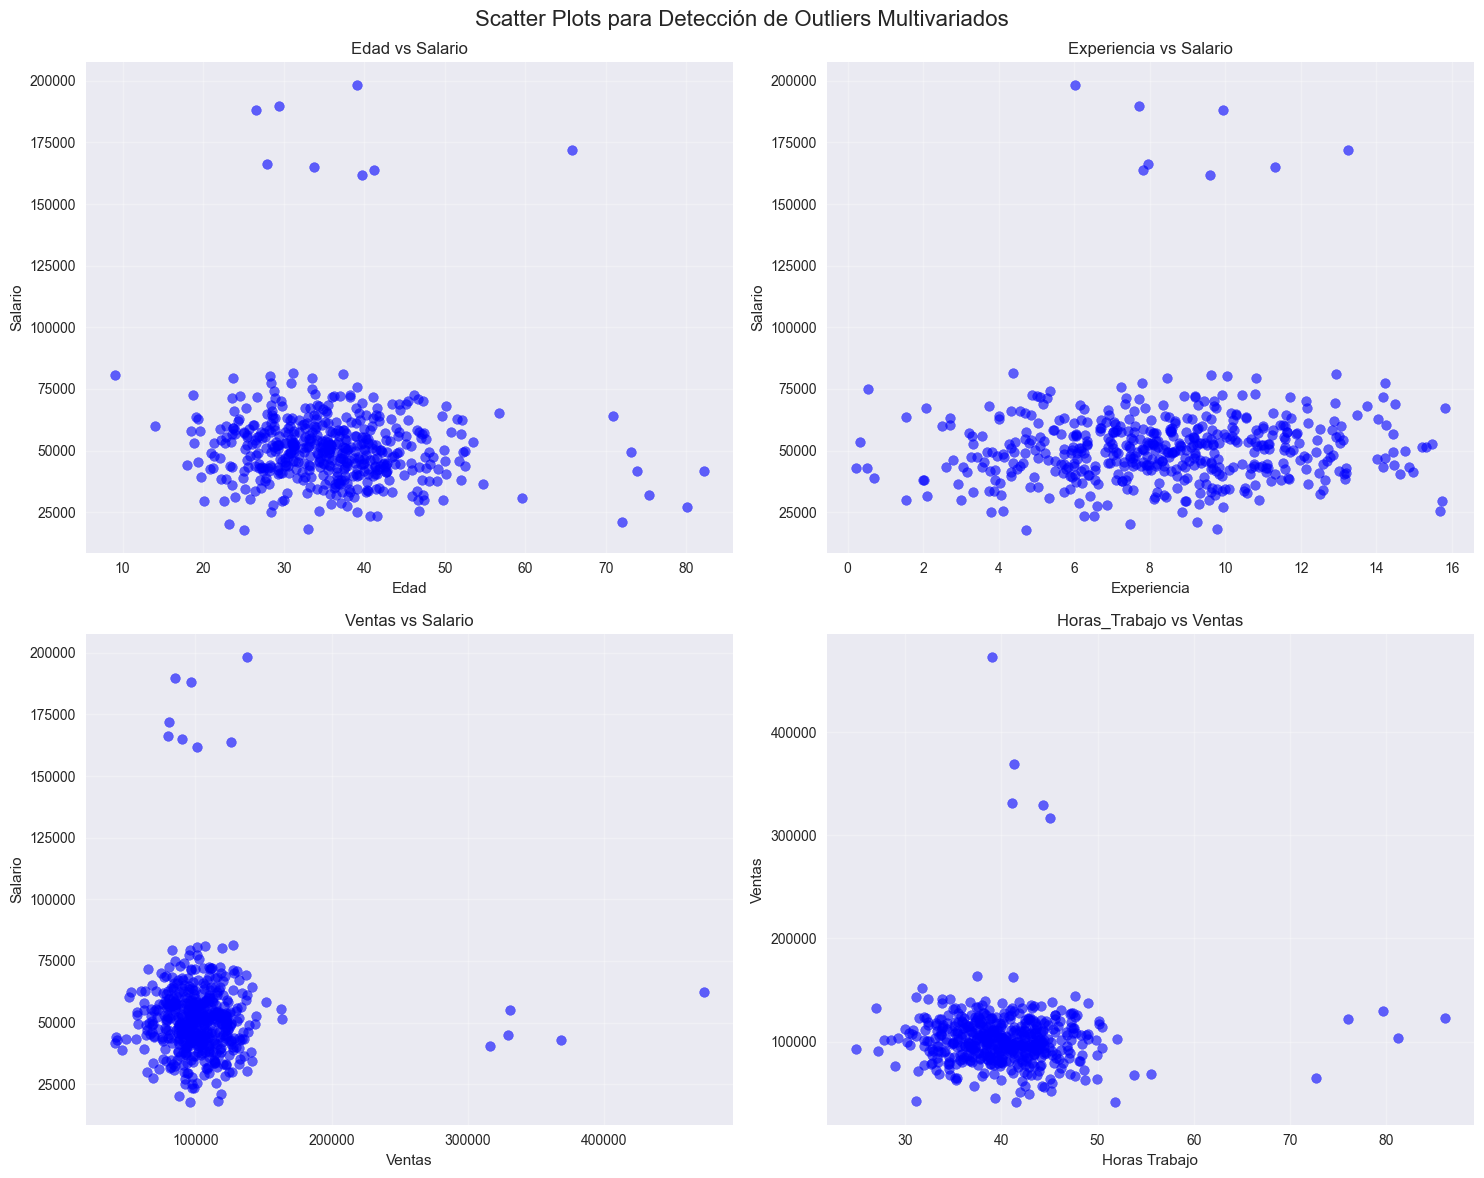

Análisis visual de distribuciones con outliers marcados:


In [8]:
# Scatter plots para detectar outliers multivariados
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Scatter Plots para Detección de Outliers Multivariados', fontsize=16)

# Combinaciones de variables para scatter plots
combinations = [
    ('edad', 'salario'),
    ('experiencia', 'salario'),
    ('ventas', 'salario'),
    ('horas_trabajo', 'ventas')
]

for i, (var_x, var_y) in enumerate(combinations):
    row, col = divmod(i, 2)
    axes[row, col].scatter(df[var_x], df[var_y], alpha=0.6, color='blue')
    axes[row, col].set_xlabel(var_x.replace('_', ' ').title())
    axes[row, col].set_ylabel(var_y.replace('_', ' ').title())
    axes[row, col].set_title(f'{var_x.title()} vs {var_y.title()}')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Histogramas con marcado de outliers
print("Análisis visual de distribuciones con outliers marcados:")

## 5. Detectar Datos Atípicos con IQR (Rango Intercuartílico)

El método IQR es una técnica robusta que usa los cuartiles para identificar outliers.

In [9]:
# Función para detectar outliers usando el método IQR
def detectar_outliers_iqr(serie, factor=1.5):
    """
    Detecta outliers usando el método del Rango Intercuartílico (IQR)
    
    Parámetros:
    - serie: pandas Series con los datos
    - factor: multiplicador para el IQR (típicamente 1.5)
    
    Retorna:
    - outliers: valores identificados como outliers
    - límites: tupla con límite inferior y superior
    """
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - factor * IQR
    limite_superior = Q3 + factor * IQR
    
    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    
    return outliers, (limite_inferior, limite_superior), (Q1, Q3, IQR)

print("DETECCIÓN DE OUTLIERS USANDO MÉTODO IQR")
print("=" * 50)

outliers_iqr = {}
estadisticas_iqr = {}

for var in variables_numericas:
    outliers, limites, stats_iqr = detectar_outliers_iqr(df[var])
    outliers_iqr[var] = outliers
    estadisticas_iqr[var] = {'limites': limites, 'stats': stats_iqr}
    
    Q1, Q3, IQR = stats_iqr
    limite_inf, limite_sup = limites
    
    print(f"\n{var.upper().replace('_', ' ')}:")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Límite inferior: {limite_inf:.2f}")
    print(f"  Límite superior: {limite_sup:.2f}")
    print(f"  Número de outliers: {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Outliers encontrados: {len(outliers)}")
        print(f"  Porcentaje del dataset: {(len(outliers)/len(df))*100:.2f}%")

DETECCIÓN DE OUTLIERS USANDO MÉTODO IQR

EDAD:
  Q1: 29.53
  Q3: 40.38
  IQR: 10.84
  Límite inferior: 13.27
  Límite superior: 56.64
  Número de outliers: 11
  Outliers encontrados: 11
  Porcentaje del dataset: 2.20%

SALARIO:
  Q1: 43030.79
  Q3: 58117.88
  IQR: 15087.09
  Límite inferior: 20400.16
  Límite superior: 80748.51
  Número de outliers: 13
  Outliers encontrados: 13
  Porcentaje del dataset: 2.60%

EXPERIENCIA:
  Q1: 6.19
  Q3: 10.26
  IQR: 4.07
  Límite inferior: 0.09
  Límite superior: 16.37
  Número de outliers: 0

VENTAS:
  Q1: 87927.71
  Q3: 114267.26
  IQR: 26339.55
  Límite inferior: 48418.39
  Límite superior: 153776.58
  Número de outliers: 11
  Outliers encontrados: 11
  Porcentaje del dataset: 2.20%

HORAS TRABAJO:
  Q1: 36.70
  Q3: 43.36
  IQR: 6.66
  Límite inferior: 26.71
  Límite superior: 53.34
  Número de outliers: 8
  Outliers encontrados: 8
  Porcentaje del dataset: 1.60%


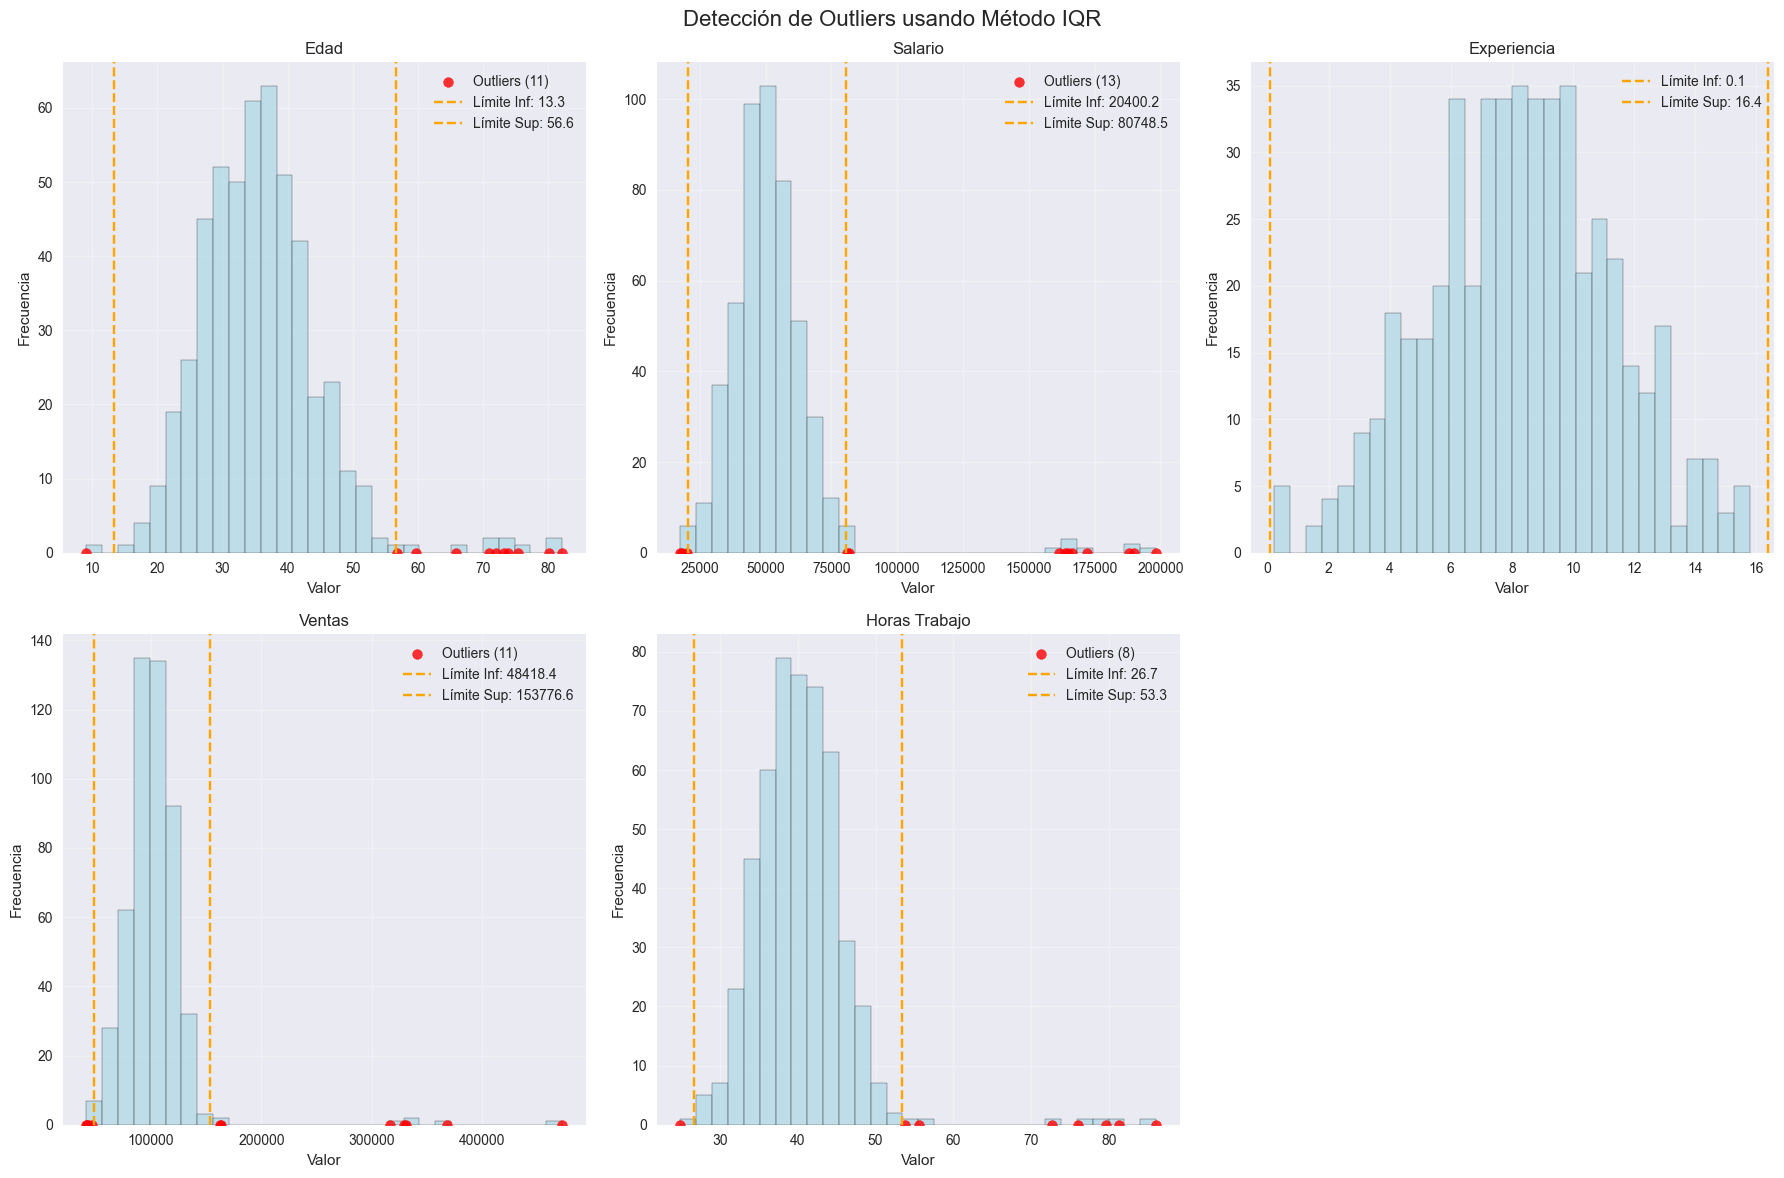

In [10]:
# Visualización de outliers detectados con IQR
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Detección de Outliers usando Método IQR', fontsize=16)

for i, var in enumerate(variables_numericas):
    row, col = divmod(i, 3)
    
    # Histograma de la variable
    axes[row, col].hist(df[var], bins=30, alpha=0.7, color='lightblue', edgecolor='black')
    
    # Marcar outliers
    outliers = outliers_iqr[var]
    if len(outliers) > 0:
        axes[row, col].scatter(outliers.values, [0]*len(outliers), 
                              color='red', s=50, alpha=0.8, label=f'Outliers ({len(outliers)})')
    
    # Marcar límites IQR
    limites = estadisticas_iqr[var]['limites']
    axes[row, col].axvline(limites[0], color='orange', linestyle='--', 
                          label=f'Límite Inf: {limites[0]:.1f}')
    axes[row, col].axvline(limites[1], color='orange', linestyle='--', 
                          label=f'Límite Sup: {limites[1]:.1f}')
    
    axes[row, col].set_title(f'{var.replace("_", " ").title()}')
    axes[row, col].set_xlabel('Valor')
    axes[row, col].set_ylabel('Frecuencia')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

# Remover el subplot vacío
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

## 6. Detectar Datos Atípicos con Z-Score

El Z-Score mide cuántas desviaciones estándar se encuentra un valor de la media.

In [11]:
# Función para calcular Z-Score y detectar outliers
def detectar_outliers_zscore(serie, umbral=3):
    """
    Detecta outliers usando Z-Score
    
    Parámetros:
    - serie: pandas Series con los datos
    - umbral: valor absoluto de Z-Score para considerar outlier
    
    Retorna:
    - outliers: valores identificados como outliers
    - z_scores: todos los z-scores calculados
    """
    media = serie.mean()
    std = serie.std()
    z_scores = np.abs((serie - media) / std)
    
    outliers = serie[z_scores > umbral]
    
    return outliers, z_scores

print("DETECCIÓN DE OUTLIERS USANDO Z-SCORE")
print("=" * 45)

outliers_zscore = {}
z_scores_todas = {}

for var in variables_numericas:
    outliers, z_scores = detectar_outliers_zscore(df[var])
    outliers_zscore[var] = outliers
    z_scores_todas[var] = z_scores
    
    print(f"\n{var.upper().replace('_', ' ')}:")
    print(f"  Media: {df[var].mean():.2f}")
    print(f"  Desviación estándar: {df[var].std():.2f}")
    print(f"  Z-Score máximo: {z_scores.max():.2f}")
    print(f"  Número de outliers (|Z| > 3): {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Porcentaje del dataset: {(len(outliers)/len(df))*100:.2f}%")
        
        # Mostrar algunos ejemplos
        ejemplos = pd.DataFrame({
            'Valor': outliers.values[:5],
            'Z-Score': z_scores[outliers.index[:5]].values
        })
        print(f"  Ejemplos de outliers:")
        print(ejemplos.to_string(index=False))

DETECCIÓN DE OUTLIERS USANDO Z-SCORE

EDAD:
  Media: 35.67
  Desviación estándar: 9.12
  Z-Score máximo: 5.10
  Número de outliers (|Z| > 3): 8
  Porcentaje del dataset: 1.60%
  Ejemplos de outliers:
    Valor  Z-Score
70.938473 3.868934
73.157604 4.112370
73.846946 4.187990
65.821852 3.307647
75.329796 4.350657

SALARIO:
  Media: 52244.65
  Desviación estándar: 19633.49
  Z-Score máximo: 7.44
  Número de outliers (|Z| > 3): 8
  Porcentaje del dataset: 1.60%
  Ejemplos de outliers:
        Valor  Z-Score
187964.625346 6.912677
164969.168685 5.741441
166312.695902 5.809871
198388.073263 7.443579
171987.024325 6.098884

EXPERIENCIA:
  Media: 8.33
  Desviación estándar: 3.02
  Z-Score máximo: 2.69
  Número de outliers (|Z| > 3): 0

VENTAS:
  Media: 103160.60
  Desviación estándar: 33135.52
  Z-Score máximo: 11.16
  Número de outliers (|Z| > 3): 5
  Porcentaje del dataset: 1.00%
  Ejemplos de outliers:
        Valor   Z-Score
329384.384717  6.827230
472931.784372 11.159361
316547.367124  6

## 7. Detectar Datos Atípicos con Isolation Forest

Isolation Forest es un algoritmo de machine learning específicamente diseñado para detectar anomalías.

In [12]:
# Preparar datos para Isolation Forest
# Seleccionar solo variables numéricas
datos_numericos = df[variables_numericas].copy()

# Estandarizar los datos (importante para algoritmos de ML)
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(datos_numericos)

# Aplicar Isolation Forest
isolation_forest = IsolationForest(contamination=0.05,  # 5% de outliers esperados
                                  random_state=42,
                                  n_estimators=100)

# Entrenar el modelo y hacer predicciones
outlier_labels = isolation_forest.fit_predict(datos_escalados)
outlier_scores = isolation_forest.decision_function(datos_escalados)

# Agregar resultados al DataFrame
df_con_outliers = df.copy()
df_con_outliers['outlier_isolation'] = outlier_labels  # -1 = outlier, 1 = normal
df_con_outliers['outlier_score'] = outlier_scores  # Menor score = más anómalo

print("DETECCIÓN DE OUTLIERS USANDO ISOLATION FOREST")
print("=" * 50)

# Contar outliers detectados
num_outliers_if = (outlier_labels == -1).sum()
print(f"Número total de outliers detectados: {num_outliers_if}")
print(f"Porcentaje del dataset: {(num_outliers_if/len(df))*100:.2f}%")

# Mostrar estadísticas de los outliers
outliers_if = df_con_outliers[df_con_outliers['outlier_isolation'] == -1]
print(f"\nEstadísticas de los outliers detectados:")
print(outliers_if[variables_numericas].describe())

DETECCIÓN DE OUTLIERS USANDO ISOLATION FOREST
Número total de outliers detectados: 25
Porcentaje del dataset: 5.00%

Estadísticas de los outliers detectados:
            edad        salario  experiencia         ventas  horas_trabajo
count  25.000000      25.000000    25.000000      25.000000      25.000000
mean   44.879536   88251.656798     7.682411  152134.998339      49.371295
std    19.129170   62902.926406     3.289787  113142.421055      15.832771
min     9.069861   20913.448080     0.226873   41192.227307      32.744122
25%    32.607941   41827.380110     6.170651   86918.486337      41.126540
50%    39.486276   55280.173401     7.610538  104023.193117      42.612571
75%    51.977250  163918.424083     9.616268  129550.601621      47.266303
max    82.135355  198388.073263    14.631569  472931.784372      86.076098


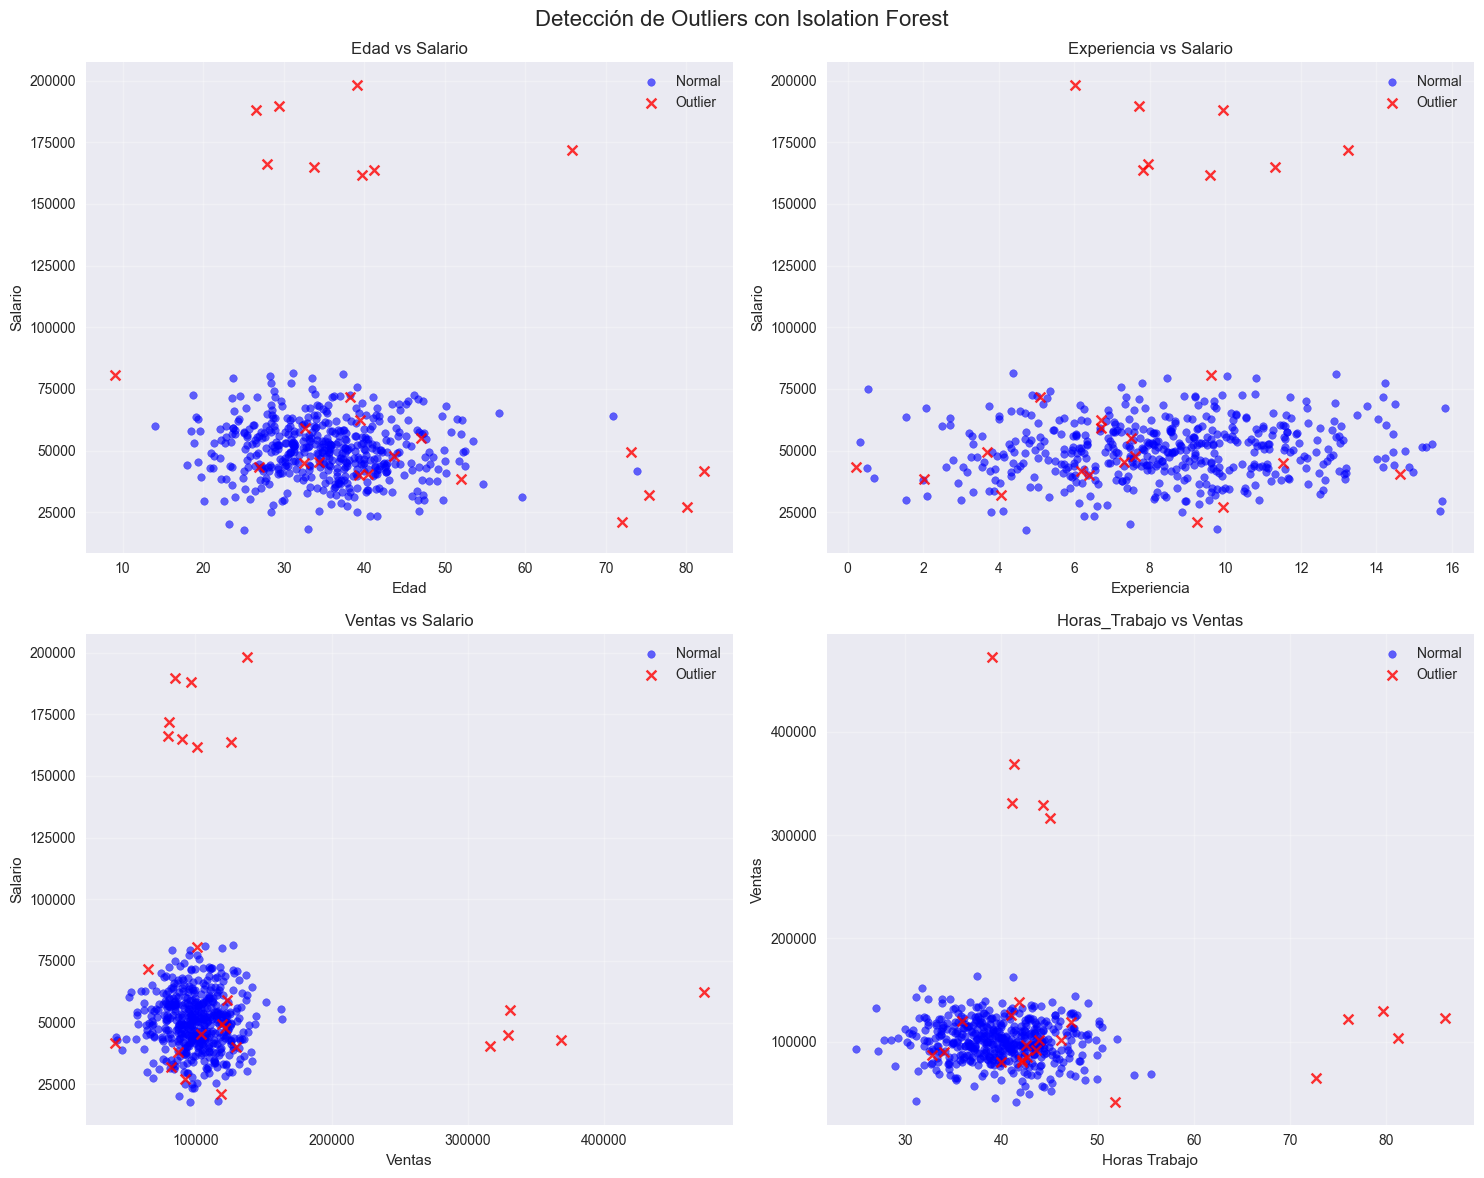

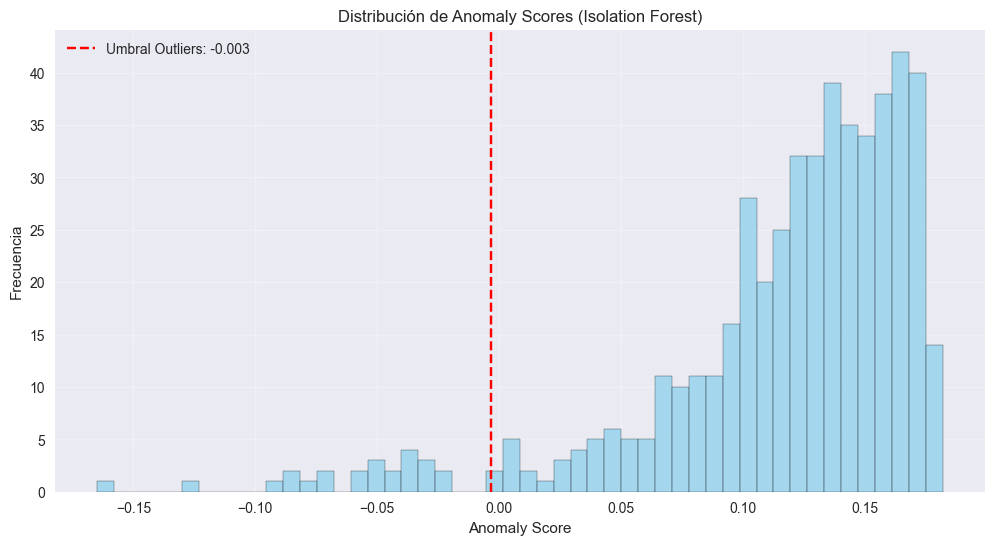

In [13]:
# Visualizar resultados de Isolation Forest
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Detección de Outliers con Isolation Forest', fontsize=16)

# Scatter plots mostrando outliers detectados
plot_combinations = [
    ('edad', 'salario'),
    ('experiencia', 'salario'),
    ('ventas', 'salario'),
    ('horas_trabajo', 'ventas')
]

for i, (var_x, var_y) in enumerate(plot_combinations):
    row, col = divmod(i, 2)
    
    # Puntos normales
    normales = df_con_outliers[df_con_outliers['outlier_isolation'] == 1]
    axes[row, col].scatter(normales[var_x], normales[var_y], 
                          alpha=0.6, color='blue', label='Normal', s=30)
    
    # Outliers
    outliers = df_con_outliers[df_con_outliers['outlier_isolation'] == -1]
    axes[row, col].scatter(outliers[var_x], outliers[var_y], 
                          alpha=0.8, color='red', label='Outlier', s=50, marker='x')
    
    axes[row, col].set_xlabel(var_x.replace('_', ' ').title())
    axes[row, col].set_ylabel(var_y.replace('_', ' ').title())
    axes[row, col].set_title(f'{var_x.title()} vs {var_y.title()}')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribución de scores de anomalía
plt.figure(figsize=(12, 6))
plt.hist(outlier_scores, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(outlier_scores[outlier_labels == -1].max(), color='red', linestyle='--', 
           label=f'Umbral Outliers: {outlier_scores[outlier_labels == -1].max():.3f}')
plt.xlabel('Anomaly Score')
plt.ylabel('Frecuencia')
plt.title('Distribución de Anomaly Scores (Isolation Forest)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Tratar Datos Atípicos - Eliminación

Una vez identificados los outliers, podemos decidir eliminarlos del dataset.

In [14]:
# Estrategia 1: Eliminar outliers usando IQR
df_sin_outliers_iqr = df.copy()

print("ELIMINACIÓN DE OUTLIERS USANDO MÉTODO IQR")
print("=" * 45)

indices_a_eliminar = set()

for var in variables_numericas:
    outliers, _, _ = detectar_outliers_iqr(df[var])
    indices_outliers = outliers.index
    indices_a_eliminar.update(indices_outliers)
    print(f"{var}: {len(indices_outliers)} outliers identificados")

print(f"\nTotal de filas únicas a eliminar: {len(indices_a_eliminar)}")
print(f"Porcentaje del dataset: {(len(indices_a_eliminar)/len(df))*100:.2f}%")

# Eliminar outliers
df_sin_outliers_iqr = df_sin_outliers_iqr.drop(indices_a_eliminar)
print(f"Dataset original: {df.shape}")
print(f"Dataset sin outliers (IQR): {df_sin_outliers_iqr.shape}")
print(f"Filas eliminadas: {len(df) - len(df_sin_outliers_iqr)}")

# Estrategia 2: Eliminar outliers usando Isolation Forest
df_sin_outliers_if = df_con_outliers[df_con_outliers['outlier_isolation'] == 1].copy()
df_sin_outliers_if = df_sin_outliers_if.drop(['outlier_isolation', 'outlier_score'], axis=1)

print(f"\nDataset sin outliers (Isolation Forest): {df_sin_outliers_if.shape}")
print(f"Filas eliminadas: {len(df) - len(df_sin_outliers_if)}")

ELIMINACIÓN DE OUTLIERS USANDO MÉTODO IQR
edad: 11 outliers identificados
salario: 13 outliers identificados
experiencia: 0 outliers identificados
ventas: 11 outliers identificados
horas_trabajo: 8 outliers identificados

Total de filas únicas a eliminar: 41
Porcentaje del dataset: 8.20%
Dataset original: (500, 6)
Dataset sin outliers (IQR): (459, 6)
Filas eliminadas: 41

Dataset sin outliers (Isolation Forest): (475, 6)
Filas eliminadas: 25


## 9. Tratar Datos Atípicos - Transformación

Las transformaciones matemáticas pueden reducir el impacto de los outliers sin eliminar datos.

In [15]:
# Crear dataset para transformaciones
df_transformado = df.copy()

print("TRANSFORMACIONES PARA REDUCIR IMPACTO DE OUTLIERS")
print("=" * 55)

# 1. Transformación logarítmica
variables_para_log = ['salario', 'ventas']  # Variables que se benefician de log

for var in variables_para_log:
    # Asegurar valores positivos (agregar 1 para evitar log(0))
    df_transformado[f'{var}_log'] = np.log(df_transformado[var] + 1)
    print(f"Transformación log aplicada a {var}")

# 2. Transformación de raíz cuadrada
variables_para_sqrt = ['horas_trabajo']

for var in variables_para_sqrt:
    df_transformado[f'{var}_sqrt'] = np.sqrt(df_transformado[var])
    print(f"Transformación raíz cuadrada aplicada a {var}")

# 3. Transformación Box-Cox (requiere valores positivos)
from scipy.stats import boxcox

for var in ['experiencia']:
    # Box-Cox requiere valores estrictamente positivos
    datos_positivos = df_transformado[var] + 1
    datos_transformados, lambda_val = boxcox(datos_positivos)
    df_transformado[f'{var}_boxcox'] = datos_transformados
    print(f"Transformación Box-Cox aplicada a {var} (λ = {lambda_val:.3f})")

print(f"\nDataset original: {df.shape}")
print(f"Dataset con transformaciones: {df_transformado.shape}")
print(f"Nuevas columnas creadas: {df_transformado.shape[1] - df.shape[1]}")

TRANSFORMACIONES PARA REDUCIR IMPACTO DE OUTLIERS
Transformación log aplicada a salario
Transformación log aplicada a ventas
Transformación raíz cuadrada aplicada a horas_trabajo
Transformación Box-Cox aplicada a experiencia (λ = 0.972)

Dataset original: (500, 6)
Dataset con transformaciones: (500, 10)
Nuevas columnas creadas: 4


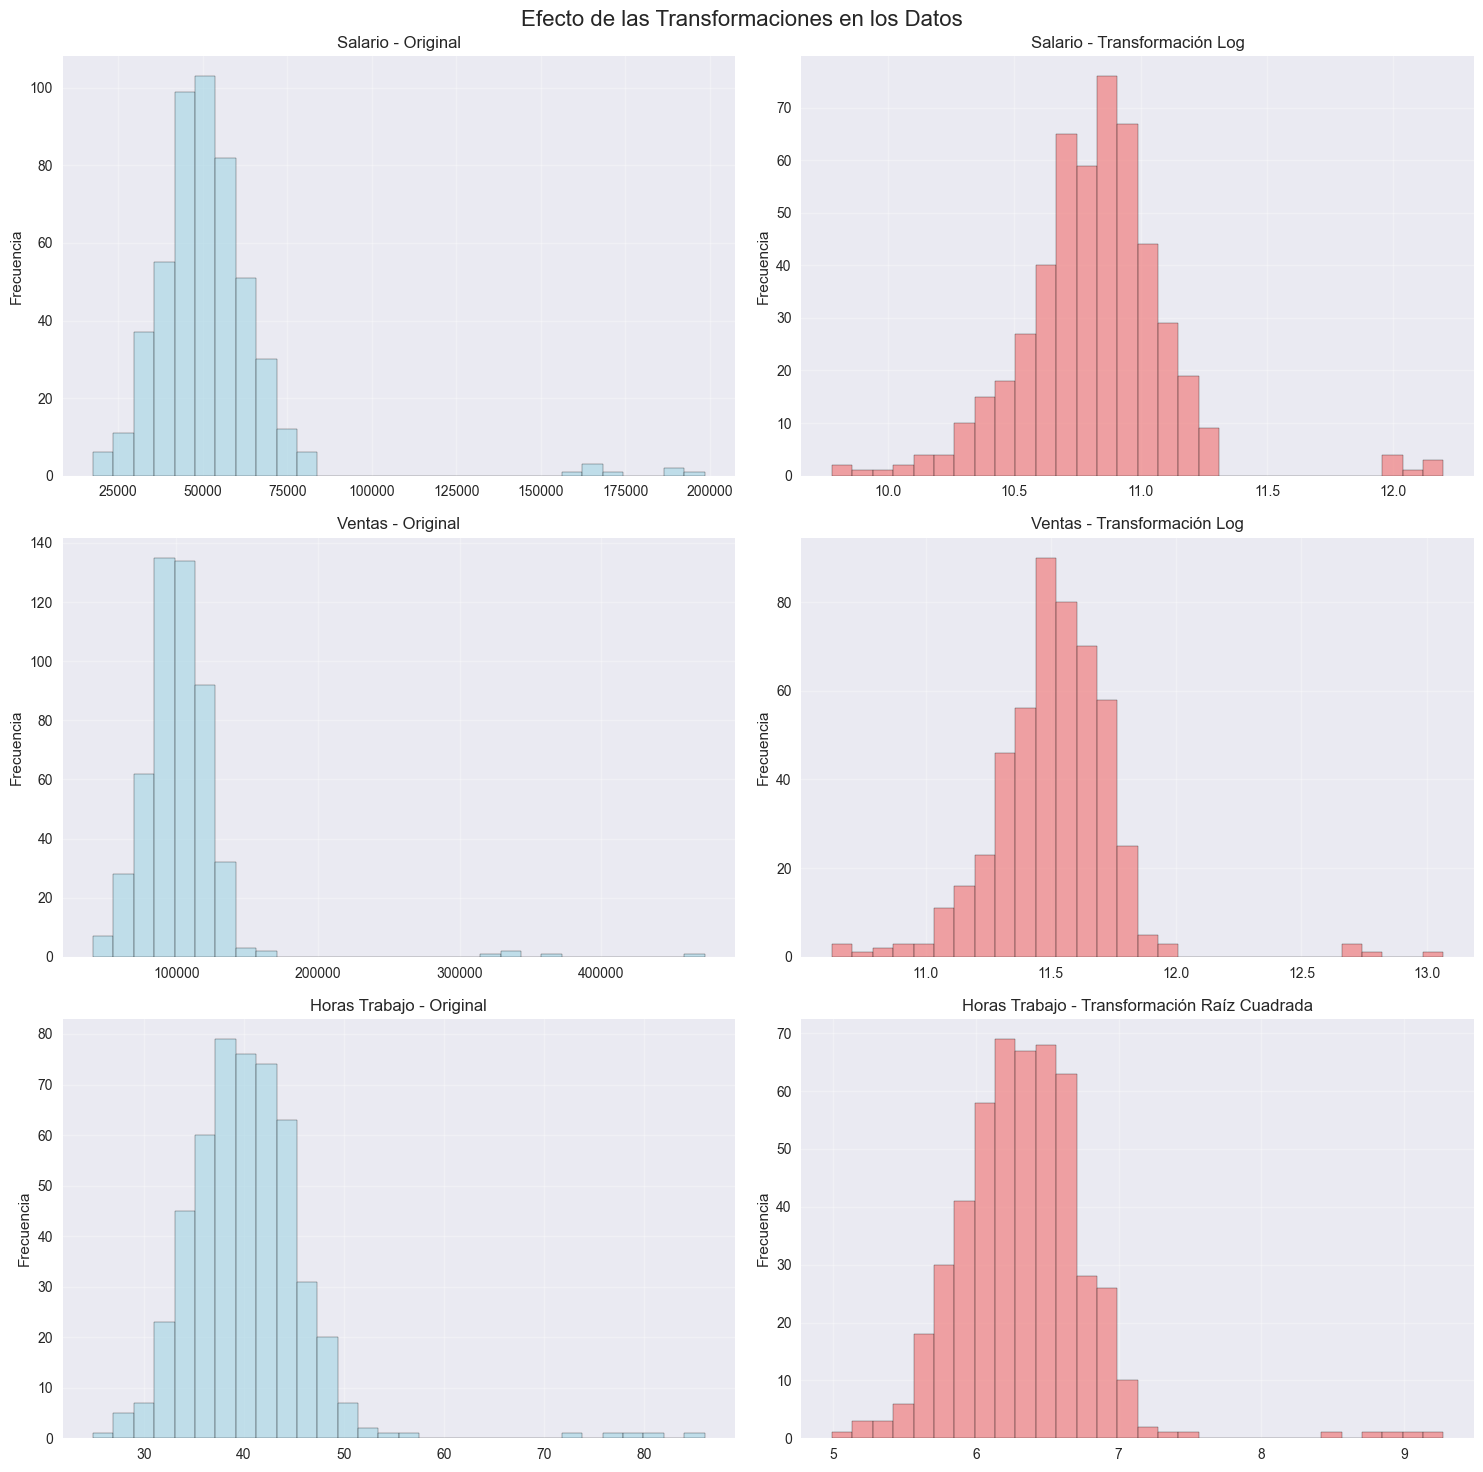


COMPARACIÓN DE ESTADÍSTICAS: ANTES VS DESPUÉS DE TRANSFORMACIONES

SALARIO:
Original - Media: 52244.65, Desv.Std: 19633.49
Transformada - Media: 10.82, Desv.Std: 0.29
Outliers originales: 13, Outliers después: 19
Reducción: -6 outliers

VENTAS:
Original - Media: 103160.60, Desv.Std: 33135.52
Transformada - Media: 11.51, Desv.Std: 0.24
Outliers originales: 11, Outliers después: 16
Reducción: -5 outliers

HORAS TRABAJO:
Original - Media: 40.29, Desv.Std: 6.18
Transformada - Media: 6.33, Desv.Std: 0.46
Outliers originales: 8, Outliers después: 9
Reducción: -1 outliers


In [16]:
# Visualizar el efecto de las transformaciones
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Efecto de las Transformaciones en los Datos', fontsize=16)

# Comparar distribuciones antes y después
transformaciones = [
    ('salario', 'salario_log', 'Transformación Log'),
    ('ventas', 'ventas_log', 'Transformación Log'),
    ('horas_trabajo', 'horas_trabajo_sqrt', 'Transformación Raíz Cuadrada')
]

for i, (original, transformada, titulo) in enumerate(transformaciones):
    # Original
    axes[i, 0].hist(df_transformado[original], bins=30, alpha=0.7, 
                   color='lightblue', edgecolor='black')
    axes[i, 0].set_title(f'{original.replace("_", " ").title()} - Original')
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Transformada
    axes[i, 1].hist(df_transformado[transformada], bins=30, alpha=0.7, 
                   color='lightcoral', edgecolor='black')
    axes[i, 1].set_title(f'{original.replace("_", " ").title()} - {titulo}')
    axes[i, 1].set_ylabel('Frecuencia')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparar estadísticas antes y después de transformaciones
print("\nCOMPARACIÓN DE ESTADÍSTICAS: ANTES VS DESPUÉS DE TRANSFORMACIONES")
print("=" * 70)

for original, transformada, _ in transformaciones:
    print(f"\n{original.upper().replace('_', ' ')}:")
    print(f"Original - Media: {df_transformado[original].mean():.2f}, "
          f"Desv.Std: {df_transformado[original].std():.2f}")
    print(f"Transformada - Media: {df_transformado[transformada].mean():.2f}, "
          f"Desv.Std: {df_transformado[transformada].std():.2f}")
    
    # Calcular reducción en outliers
    outliers_orig, _, _ = detectar_outliers_iqr(df_transformado[original])
    outliers_trans, _, _ = detectar_outliers_iqr(df_transformado[transformada])
    print(f"Outliers originales: {len(outliers_orig)}, "
          f"Outliers después: {len(outliers_trans)}")
    print(f"Reducción: {len(outliers_orig) - len(outliers_trans)} outliers")

## 10. Tratar Datos Atípicos - Imputación

En lugar de eliminar outliers, podemos reemplazarlos con valores más apropiados.

In [17]:
# Crear dataset para imputación
df_imputado = df.copy()

print("IMPUTACIÓN DE OUTLIERS")
print("=" * 25)

# Estrategia 1: Reemplazar outliers con percentiles
def imputar_outliers_percentiles(serie, percentil_inferior=5, percentil_superior=95):
    """
    Reemplaza outliers con valores de percentiles específicos
    """
    limite_inf = serie.quantile(percentil_inferior/100)
    limite_sup = serie.quantile(percentil_superior/100)
    
    serie_imputada = serie.copy()
    serie_imputada[serie < limite_inf] = limite_inf
    serie_imputada[serie > limite_sup] = limite_sup
    
    return serie_imputada

# Estrategia 2: Reemplazar outliers IQR con mediana
def imputar_outliers_iqr_mediana(serie):
    """
    Reemplaza outliers detectados por IQR con la mediana
    """
    outliers, _, _ = detectar_outliers_iqr(serie)
    serie_imputada = serie.copy()
    mediana = serie.median()
    
    for idx in outliers.index:
        serie_imputada[idx] = mediana
    
    return serie_imputada, len(outliers)

print("Aplicando imputación de outliers...")

for var in variables_numericas:
    # Método 1: Winsorización (percentiles)
    df_imputado[f'{var}_winsorized'] = imputar_outliers_percentiles(df[var])
    
    # Método 2: Reemplazo con mediana
    df_imputado[f'{var}_mediana'], num_reemplazos = imputar_outliers_iqr_mediana(df[var])
    
    print(f"{var}: {num_reemplazos} outliers reemplazados con mediana")

print(f"\nDataset original: {df.shape}")
print(f"Dataset con imputaciones: {df_imputado.shape}")
print(f"Columnas agregadas: {df_imputado.shape[1] - df.shape[1]}")

IMPUTACIÓN DE OUTLIERS
Aplicando imputación de outliers...
edad: 11 outliers reemplazados con mediana
salario: 13 outliers reemplazados con mediana
experiencia: 0 outliers reemplazados con mediana
ventas: 11 outliers reemplazados con mediana
horas_trabajo: 8 outliers reemplazados con mediana

Dataset original: (500, 6)
Dataset con imputaciones: (500, 16)
Columnas agregadas: 10


## 11. Comparar Resultados Antes y Después del Tratamiento

Evaluemos el impacto de cada método de tratamiento en nuestros datos.

In [19]:
# Función para crear reporte comparativo
def reporte_comparativo(df_original, df_tratado, nombre_tratamiento, variable='salario'):
    """
    Genera un reporte comparativo antes y después del tratamiento
    """
    print(f"\n=== REPORTE: {nombre_tratamiento.upper()} ===")
    print(f"Variable analizada: {variable}")
    
    # Estadísticas básicas
    print(f"\nEstadísticas descriptivas:")
    print(f"Original - Media: {df_original[variable].mean():.2f}, "
          f"Mediana: {df_original[variable].median():.2f}, "
          f"Desv.Std: {df_original[variable].std():.2f}")
    print(f"Tratado  - Media: {df_tratado[variable].mean():.2f}, "
          f"Mediana: {df_tratado[variable].median():.2f}, "
          f"Desv.Std: {df_tratado[variable].std():.2f}")
    
    # Outliers restantes
    outliers_orig, _, _ = detectar_outliers_iqr(df_original[variable])
    outliers_trat, _, _ = detectar_outliers_iqr(df_tratado[variable])
    
    print(f"\nOutliers (método IQR):")
    print(f"Original: {len(outliers_orig)} ({(len(outliers_orig)/len(df_original))*100:.2f}%)")
    print(f"Tratado:  {len(outliers_trat)} ({(len(outliers_trat)/len(df_tratado))*100:.2f}%)")
    print(f"Reducción: {len(outliers_orig) - len(outliers_trat)} outliers")
    
    # Tamaño del dataset
    print(f"\nTamaño del dataset:")
    print(f"Original: {len(df_original)} filas")
    print(f"Tratado:  {len(df_tratado)} filas")
    print(f"Diferencia: {len(df_original) - len(df_tratado)} filas")

# Generar reportes comparativos
variable_analisis = 'salario'

# 1. Eliminación con IQR
reporte_comparativo(df, df_sin_outliers_iqr, "Eliminación (IQR)", variable_analisis)

# 2. Eliminación con Isolation Forest
reporte_comparativo(df, df_sin_outliers_if, "Eliminación (Isolation Forest)", variable_analisis)

# 3. Transformación logarítmica
reporte_comparativo(df, df_transformado, "Transformación Log", variable_analisis)

# 4. Imputación con mediana - Comparar columna original vs columna imputada
def reporte_comparativo_imputacion(df_original, df_imputado, variable_original, variable_imputada):
    """Reporte especializado para comparar imputación"""
    print(f"\n=== REPORTE: IMPUTACIÓN (MEDIANA) ===")
    print(f"Variable analizada: {variable_original} → {variable_imputada}")
    
    # Estadísticas básicas
    print(f"\nEstadísticas descriptivas:")
    print(f"Original - Media: {df_original[variable_original].mean():.2f}, "
          f"Mediana: {df_original[variable_original].median():.2f}, "
          f"Desv.Std: {df_original[variable_original].std():.2f}")
    print(f"Imputado - Media: {df_imputado[variable_imputada].mean():.2f}, "
          f"Mediana: {df_imputado[variable_imputada].median():.2f}, "
          f"Desv.Std: {df_imputado[variable_imputada].std():.2f}")
    
    # Outliers restantes
    outliers_orig, _, _ = detectar_outliers_iqr(df_original[variable_original])
    outliers_imp, _, _ = detectar_outliers_iqr(df_imputado[variable_imputada])
    
    print(f"\nOutliers (método IQR):")
    print(f"Original: {len(outliers_orig)} ({(len(outliers_orig)/len(df_original))*100:.2f}%)")
    print(f"Imputado: {len(outliers_imp)} ({(len(outliers_imp)/len(df_imputado))*100:.2f}%)")
    print(f"Reducción: {len(outliers_orig) - len(outliers_imp)} outliers")
    
    # Tamaño del dataset (mismo para imputación)
    print(f"\nTamaño del dataset:")
    print(f"Original: {len(df_original)} filas")
    print(f"Imputado: {len(df_imputado)} filas (sin pérdida de datos)")

# Usar la función especializada para imputación
reporte_comparativo_imputacion(df, df_imputado, variable_analisis, f"{variable_analisis}_mediana")


=== REPORTE: ELIMINACIÓN (IQR) ===
Variable analizada: salario

Estadísticas descriptivas:
Original - Media: 52244.65, Mediana: 50351.01, Desv.Std: 19633.49
Tratado  - Media: 50463.79, Mediana: 50357.07, Desv.Std: 11183.31

Outliers (método IQR):
Original: 13 (2.60%)
Tratado:  1 (0.22%)
Reducción: 12 outliers

Tamaño del dataset:
Original: 500 filas
Tratado:  459 filas
Diferencia: 41 filas

=== REPORTE: ELIMINACIÓN (ISOLATION FOREST) ===
Variable analizada: salario

Estadísticas descriptivas:
Original - Media: 52244.65, Mediana: 50351.01, Desv.Std: 19633.49
Tratado  - Media: 50349.55, Mediana: 50344.94, Desv.Std: 11553.42

Outliers (método IQR):
Original: 13 (2.60%)
Tratado:  6 (1.26%)
Reducción: 7 outliers

Tamaño del dataset:
Original: 500 filas
Tratado:  475 filas
Diferencia: 25 filas

=== REPORTE: TRANSFORMACIÓN LOG ===
Variable analizada: salario

Estadísticas descriptivas:
Original - Media: 52244.65, Mediana: 50351.01, Desv.Std: 19633.49
Tratado  - Media: 52244.65, Mediana: 5035

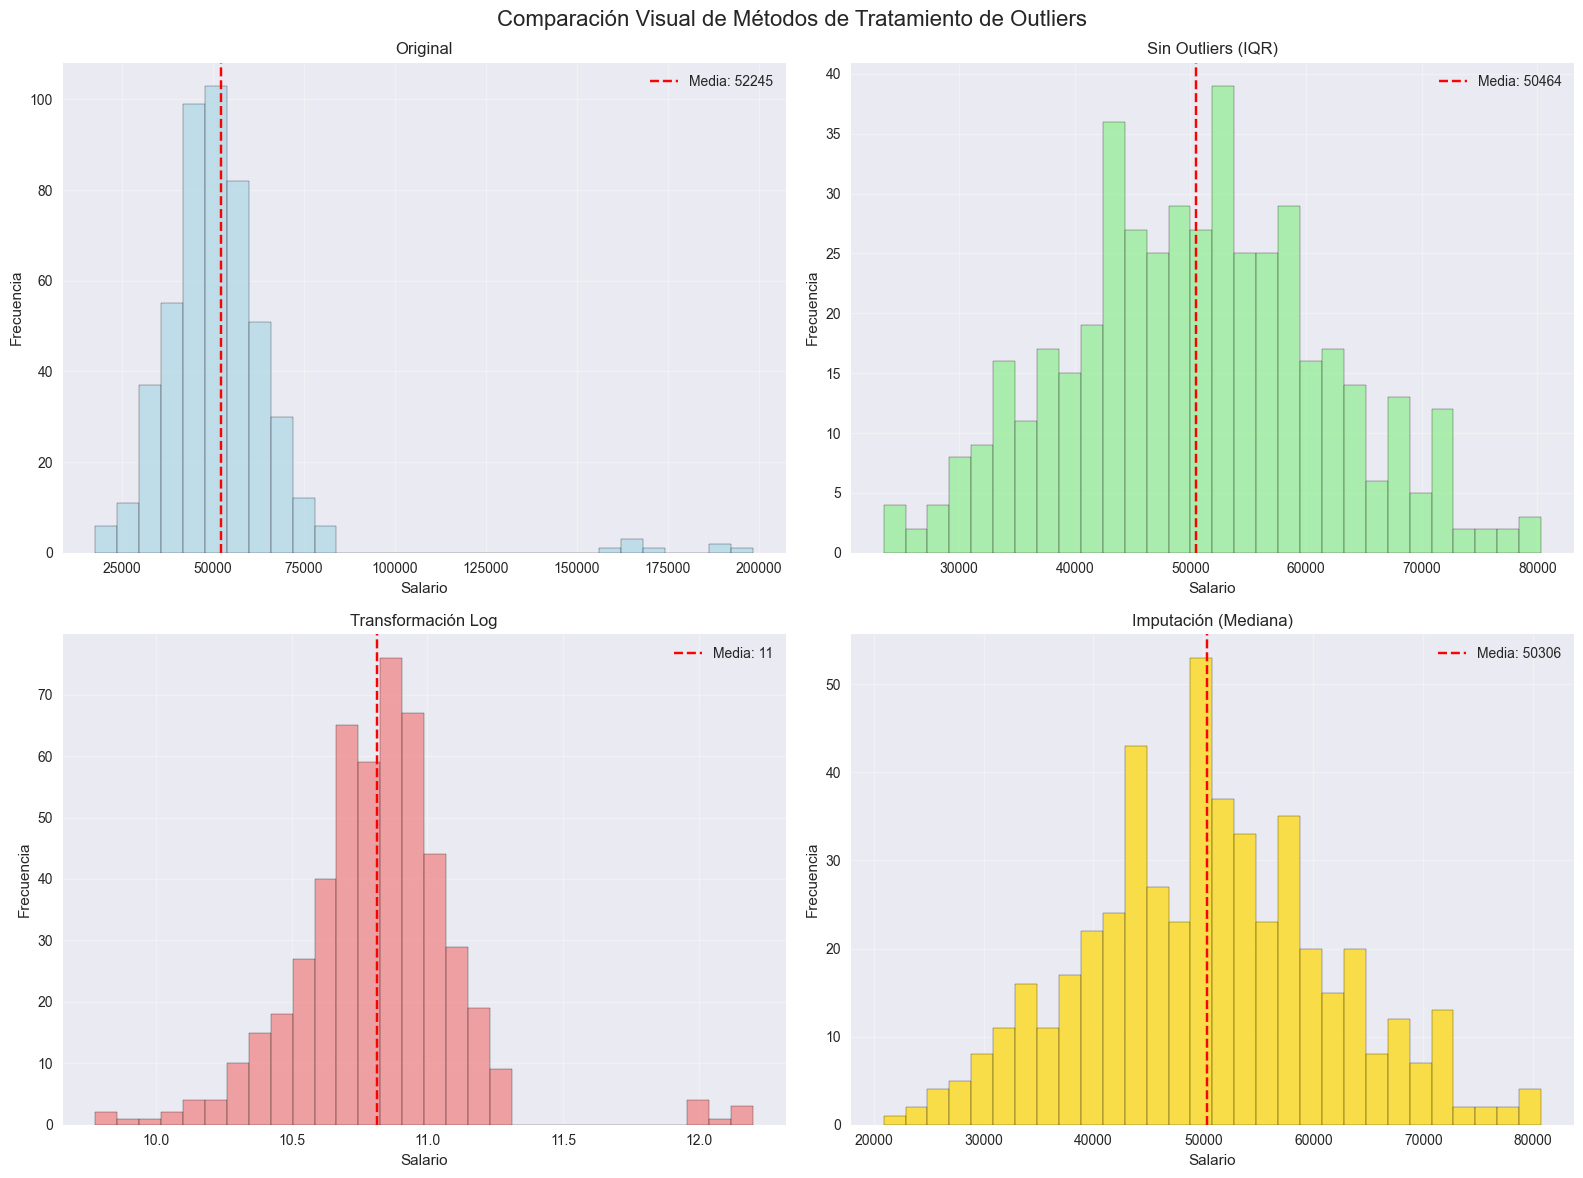


RESUMEN FINAL DE MÉTODOS DE TRATAMIENTO DE OUTLIERS
Dataset original: 500 filas
• Eliminación IQR: 459 filas restantes (91.8%)
• Eliminación IF: 475 filas restantes (95.0%)
• Transformación: 500 filas (100% preservadas)
• Imputación: 500 filas (100% preservadas)

Recomendaciones:
• Eliminación: Usar cuando los outliers son errores de medición
• Transformación: Mejor para datos con asimetría natural
• Imputación: Cuando no puedes permitirte perder datos
• Isolation Forest: Excelente para detección multivariada


In [20]:
# Visualización comparativa final
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparación Visual de Métodos de Tratamiento de Outliers', fontsize=16)

datasets_comparacion = [
    (df[variable_analisis], 'Original'),
    (df_sin_outliers_iqr[variable_analisis], 'Sin Outliers (IQR)'),
    (df_transformado[f'{variable_analisis}_log'], 'Transformación Log'),
    (df_imputado[f'{variable_analisis}_mediana'], 'Imputación (Mediana)')
]

colors = ['lightblue', 'lightgreen', 'lightcoral', 'gold']

for i, (data, titulo) in enumerate(datasets_comparacion):
    row, col = divmod(i, 2)
    
    axes[row, col].hist(data, bins=30, alpha=0.7, color=colors[i], edgecolor='black')
    axes[row, col].set_title(titulo)
    axes[row, col].set_xlabel('Salario')
    axes[row, col].set_ylabel('Frecuencia')
    axes[row, col].grid(True, alpha=0.3)
    
    # Agregar estadísticas al gráfico
    media = data.mean()
    std = data.std()
    axes[row, col].axvline(media, color='red', linestyle='--', 
                          label=f'Media: {media:.0f}')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

# Resumen final
print("\n" + "="*70)
print("RESUMEN FINAL DE MÉTODOS DE TRATAMIENTO DE OUTLIERS")
print("="*70)
print(f"Dataset original: {df.shape[0]} filas")
print(f"• Eliminación IQR: {df_sin_outliers_iqr.shape[0]} filas restantes "
      f"({((df_sin_outliers_iqr.shape[0]/df.shape[0])*100):.1f}%)")
print(f"• Eliminación IF: {df_sin_outliers_if.shape[0]} filas restantes "
      f"({((df_sin_outliers_if.shape[0]/df.shape[0])*100):.1f}%)")
print(f"• Transformación: {df_transformado.shape[0]} filas (100% preservadas)")
print(f"• Imputación: {df_imputado.shape[0]} filas (100% preservadas)")

print("\nRecomendaciones:")
print("• Eliminación: Usar cuando los outliers son errores de medición")
print("• Transformación: Mejor para datos con asimetría natural")
print("• Imputación: Cuando no puedes permitirte perder datos")
print("• Isolation Forest: Excelente para detección multivariada")

## Resumen y Mejores Prácticas

### 🎯 Técnicas Aprendidas

1. **Detección de Outliers:**
   - **Métodos estadísticos:** Media ± 3σ, MAD
   - **IQR (Rango Intercuartílico):** Q1 - 1.5×IQR, Q3 + 1.5×IQR
   - **Z-Score:** |Z| > 3 (o 2.5)
   - **Isolation Forest:** Algoritmo de ML para anomalías multivariadas

2. **Visualización:**
   - **Boxplots:** Identificación visual rápida
   - **Histogramas:** Distribución y forma de los datos
   - **Scatter plots:** Outliers multivariados

3. **Estrategias de Tratamiento:**
   - **Eliminación:** Remover completamente los outliers
   - **Transformación:** Log, raíz cuadrada, Box-Cox
   - **Imputación:** Reemplazar con mediana, percentiles (Winsorización)

### 📋 Guía de Decisión

**¿Qué método usar?**

| Situación | Método Recomendado | Cuándo NO usar |
|-----------|-------------------|----------------|
| **Errores de medición** | Eliminación | Si reduces mucho el tamaño |
| **Datos naturalmente sesgados** | Transformación | Con distribuciones normales |
| **Valores extremos válidos** | Imputación/Winsorización | Si el extremo es importante |
| **Análisis multivariado** | Isolation Forest | Con pocas variables |

### 🔧 Consejos Prácticos

1. **Siempre explora primero:** Entiende el contexto de los outliers
2. **Combina métodos:** Usa visualización + estadísticas + algoritmos
3. **Considera el dominio:** Los outliers pueden ser los datos más importantes
4. **Documenta decisiones:** Justifica por qué elegiste cada método
5. **Valida resultados:** Compara distribuciones antes/después

### ⚠️ Advertencias Importantes

- **No elimines automáticamente:** Los outliers pueden contener información valiosa
- **Transformaciones cambian interpretación:** Log(salario) ≠ salario
- **IQR es robusto:** Menos sensible a outliers extremos que métodos basados en media
- **Isolation Forest requiere suficientes datos:** Mínimo 100-200 observaciones

### 🚀 Próximos Pasos

1. Practica con tus propios datasets
2. Experimenta con diferentes umbrales
3. Combina técnicas según el contexto
4. Considera métodos más avanzados (LOF, DBSCAN)

¡Has completado exitosamente la guía de tratamiento de datos atípicos! 🎉